In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\ML Sberbank


In [3]:
data = pd.read_csv(current_directory+"/train.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [4]:
df.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

# 📊 Pregled glavnih feature-a u Sberbank datasetu
## 🎯 Target
- **`price_doc`** → Cena stana (target varijabla koju predviđamo).
## 📑 Identifikacioni
- **`id`** → Identifikator transakcije (samo ID, ne utiče na model).
- **`timestamp`** → Datum transakcije (važan za sezonske efekte i vremenske trendove).
## 🏠 Karakteristike stana
- **`full_sq`** → Ukupna površina stana (uključuje balkone, lođe, hodnike).
- **`life_sq`** → Stambena površina (samo sobe, bez balkona i pomoćnih prostorija).
- **`kitch_sq`** → Površina kuhinje.
- **`num_room`** → Broj soba.
## 🏢 Karakteristike zgrade
- **`floor`** → Sprat na kojem se stan nalazi.
- **`max_floor`** → Ukupan broj spratova u zgradi.
- **`material`** → Materijal zidova (npr. cigla, panel, monolit).
- **`build_year`** → Godina izgradnje zgrade.
- **`state`** → Stanje stana (npr. novogradnja, renoviran, za renoviranje).
## 💰 Tip kupovine
- **`product_type`** → Tip transakcije:
  - *Owner-occupier purchase* → Kupovina za sopstveno stanovanje
  - *Investment* → Investiciona kupovina
## 🌍 Lokacija
- **`sub_area`** → Naziv distrikta (naselja) u Moskvi gde se stan nalazi.


In [6]:
df.shape

(30471, 292)

In [7]:
target = df["price_doc"]
target = pd.DataFrame(target)

In [8]:
print(target.isna().sum())

price_doc    0
dtype: int64


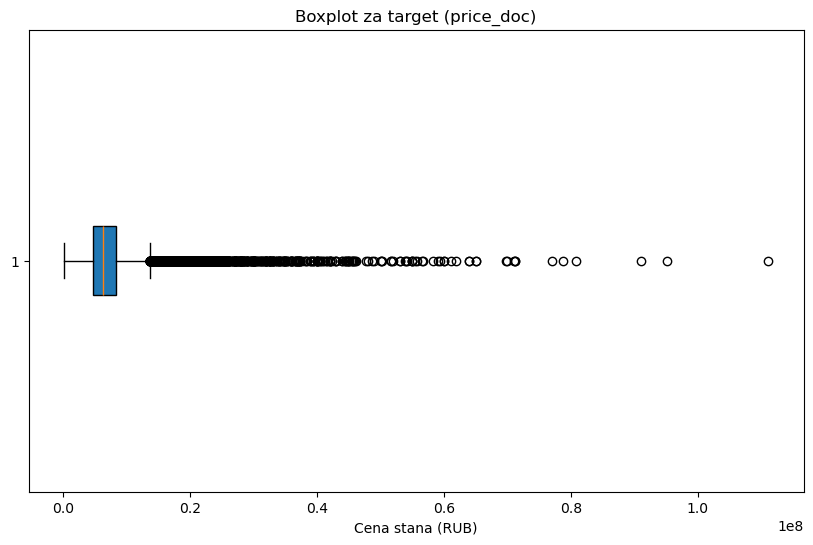

In [9]:
plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

In [10]:
# df = df.dropna(subset=["price_doc"])

In [11]:
# 1. IQR filtering
Q1 = df["price_doc"].quantile(0.25)
Q3 = df["price_doc"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df["price_doc"] >= lower_bound) & (df["price_doc"] <= upper_bound)]

# 2. Random sample od 10k redova
df_small = df_clean.sample(n=10000, random_state=42)

print(df.shape, "-> original")
print(df_clean.shape, "-> posle IQR")
print(df_small.shape, "-> posle samplinga")

(30471, 292) -> original
(28589, 292) -> posle IQR
(10000, 292) -> posle samplinga


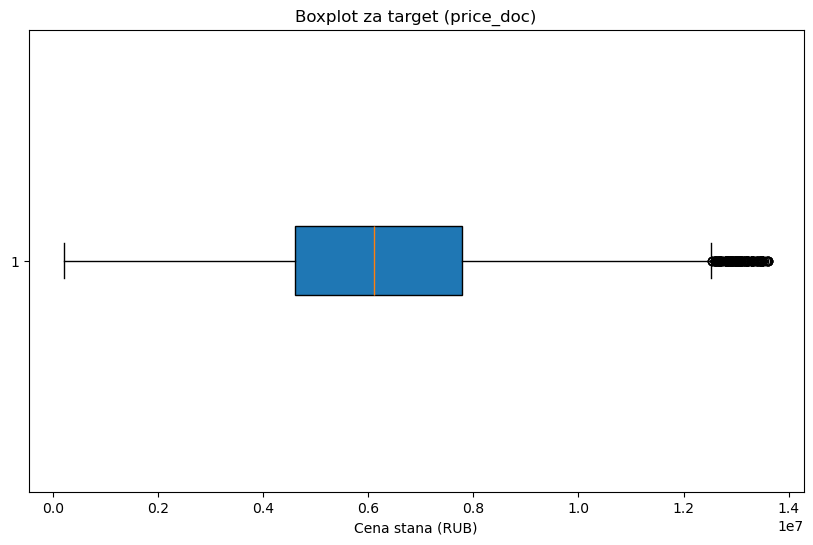

In [12]:
plt.figure(figsize=(10,6))
plt.boxplot(df_small["price_doc"], vert=False, patch_artist=True)

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

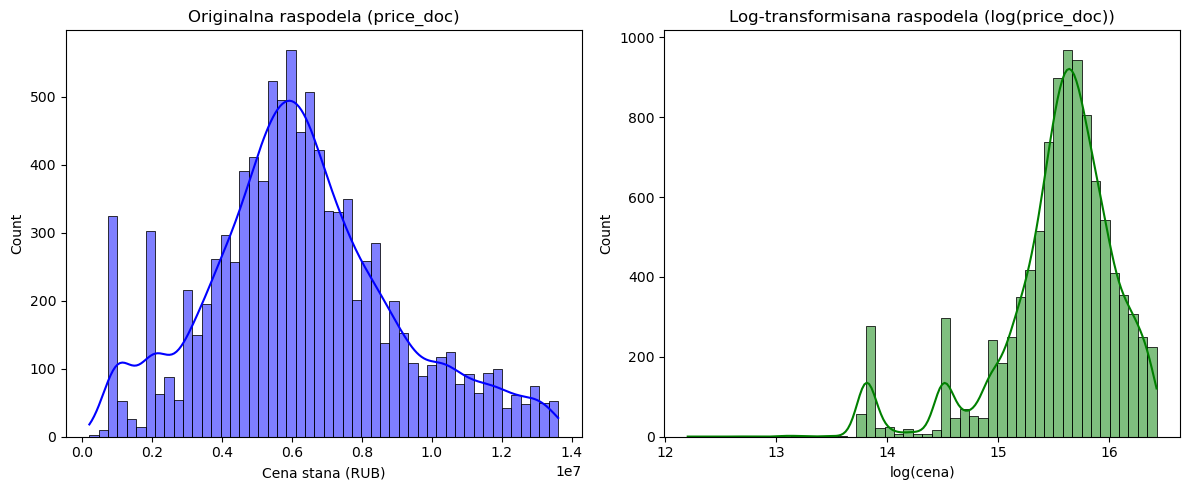

In [13]:
import seaborn as sns

# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_small["price_doc"], kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(df_small["price_doc"]), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()


In [14]:

# pretpostavimo da je df_clean tvoj očišćeni DataFrame (bez NaN i outliera)

# 1. Podela targeta na 10 klasa (decile) preko qcut
df_small["price_class"], bins = pd.qcut(
    df_small["price_doc"],
    q=10,                 # broj klasa = 10
    labels=False,         # klase od 0 do 9
    retbins=True,         # vrati i granice binova
    duplicates="drop"     # ako ima duplikata u percentilima
)

# 2. Pregled granica klasa
print("Granice binova (decile):")
print(bins)

# 3. Napravi tabelu sa brojem stanova po klasi
summary = pd.DataFrame({
    "class": range(len(bins)-1),
    "from_price": bins[:-1],
    "to_price": bins[1:],
    "count": df_small.groupby("price_class")["price_doc"].count().values
})

print(summary)


Granice binova (decile):
[  200000.   3000000.   4189654.4  5000000.   5553751.2  6100000.
  6600000.   7330878.6  8300000.  10100000.  13615630. ]
   class  from_price    to_price  count
0      0    200000.0   3000000.0   1081
1      1   3000000.0   4189654.4    919
2      2   4189654.4   5000000.0   1091
3      3   5000000.0   5553751.2    909
4      4   5553751.2   6100000.0   1077
5      5   6100000.0   6600000.0    932
6      6   6600000.0   7330878.6    991
7      7   7330878.6   8300000.0   1012
8      8   8300000.0  10100000.0    993
9      9  10100000.0  13615630.0    995


In [15]:
df_small.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [16]:
def missing_values_ratio(df, ratio_for_na_values=0.3, target_col="price_doc"):
    # 1. Missing ratio for each column
    missing_ratio = df.isnull().mean().sort_values(ascending=False)
    
    # 2. Select only columns with > threshold % missing
    cols_over_n = missing_ratio[missing_ratio > ratio_for_na_values]
    
    if not cols_over_n.empty:
        print(f"Kolone sa preko {round(ratio_for_na_values*100)}% nedostajućih vrednosti:\n")
        
        # 3. For each such column, compute correlation with target
        for col in cols_over_n.index:
            if df[col].dtype in ['int64', 'float64']:  # only numeric can correlate
                corr_val = df[[col, target_col]].corr().iloc[0, 1]  # correlation col <-> target
                print(f"{col}: {cols_over_n[col]*100:.2f}% NaN, korelacija sa targetom = {corr_val:.3f}")
    else:
        print("Nema takvih kolona")

In [17]:
missing_values_ratio(df, 0.3)

Kolone sa preko 30% nedostajućih vrednosti:

hospital_beds_raion: 47.39% NaN, korelacija sa targetom = 0.147
build_year: 44.65% NaN, korelacija sa targetom = 0.002
state: 44.50% NaN, korelacija sa targetom = 0.121
cafe_avg_price_500: 43.59% NaN, korelacija sa targetom = 0.037
cafe_sum_500_max_price_avg: 43.59% NaN, korelacija sa targetom = 0.038
cafe_sum_500_min_price_avg: 43.59% NaN, korelacija sa targetom = 0.036
max_floor: 31.41% NaN, korelacija sa targetom = 0.094
material: 31.41% NaN, korelacija sa targetom = 0.064
num_room: 31.41% NaN, korelacija sa targetom = 0.476
kitch_sq: 31.41% NaN, korelacija sa targetom = 0.029


In [18]:
columns_to_drop = ['hospital_beds_raion','build_year','state','cafe_avg_price_500','cafe_sum_500_max_price_avg','cafe_sum_500_min_price_avg']
df.drop(columns="timestamp", inplace=True)

In [19]:
obj_cols = df.select_dtypes(include=["object"]).columns
df_obj = df.select_dtypes(include=["object"])

print("Object kolone:")
print(obj_cols)

Object kolone:
Index(['product_type', 'sub_area', 'culture_objects_top_25',
       'thermal_power_plant_raion', 'incineration_raion',
       'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion',
       'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion',
       'water_1line', 'big_road1_1line', 'railroad_1line', 'ecology'],
      dtype='object')


In [20]:
df_obj.head()

,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,water_1line,big_road1_1line,railroad_1line,ecology
0,Investment,Bibirevo,no,no,no,no,no,no,no,no,no,no,no,no,good
1,Investment,Nagatinskij Zaton,yes,no,no,no,no,no,no,no,no,no,no,no,excellent
2,Investment,Tekstil'shhiki,no,no,no,no,yes,no,no,no,no,no,no,no,poor
3,Investment,Mitino,no,no,no,no,no,no,no,no,no,no,no,no,good
4,Investment,Basmannoe,no,no,no,no,yes,yes,no,no,no,no,no,yes,excellent


In [21]:
for oc in obj_cols:
    print(oc)
    print(df[oc].unique())

print(len(obj_cols))

product_type
['Investment' 'OwnerOccupier']
sub_area
['Bibirevo' 'Nagatinskij Zaton' "Tekstil'shhiki" 'Mitino' 'Basmannoe'
 'Nizhegorodskoe' "Sokol'niki" 'Koptevo' 'Kuncevo' 'Kosino-Uhtomskoe'
 'Zapadnoe Degunino' 'Presnenskoe' 'Lefortovo' "Mar'ino" "Kuz'minki"
 'Nagornoe' "Gol'janovo" 'Vnukovo' 'Juzhnoe Tushino' 'Severnoe Tushino'
 "Chertanovo Central'noe" 'Fili Davydkovo' 'Otradnoe' 'Novo-Peredelkino'
 'Bogorodskoe' 'Jaroslavskoe' 'Strogino' 'Hovrino' "Moskvorech'e-Saburovo"
 'Staroe Krjukovo' 'Ljublino' 'Caricyno' 'Veshnjaki' 'Danilovskoe'
 'Preobrazhenskoe' "Kon'kovo" 'Brateevo' 'Vostochnoe Izmajlovo'
 'Vyhino-Zhulebino' 'Donskoe' 'Novogireevo' 'Juzhnoe Butovo' 'Sokol'
 'Kurkino' 'Izmajlovo' 'Severnoe Medvedkovo' 'Rostokino'
 'Orehovo-Borisovo Severnoe' 'Ochakovo-Matveevskoe' 'Taganskoe'
 'Dmitrovskoe' 'Orehovo-Borisovo Juzhnoe' 'Teplyj Stan' 'Babushkinskoe'
 'Pokrovskoe Streshnevo' 'Obruchevskoe' 'Filevskij Park'
 'Troparevo-Nikulino' 'Severnoe Butovo' 'Hamovniki' 'Solncevo'
 'Dor

In [22]:
#corr = df.corr()["price_doc"]

In [23]:
nominal_cols = ["culture_objects_top_25","thermal_power_plant_raion","incineration_raion","oil_chemistry_raion","radiation_raion","railroad_terminal_raion","big_market_raion","nuclear_reactor_raion",
               "detention_facility_raion","water_1line","big_road1_1line","railroad_1line","product_type"] 
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]

In [24]:
from sklearn.impute import SimpleImputer

df_obj["ecology"] = df_obj["ecology"].replace("no data", np.nan)
df_obj = df_obj.replace(["nan", "NaN", ""], np.nan)
imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
df_obj = imputer.fit_transform(df_obj)
df_obj = pd.DataFrame(df_obj)

In [25]:
df_obj.isna().sum().sum()

0

In [26]:
df_obj.head()

,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,water_1line,big_road1_1line,railroad_1line,ecology
0,Investment,Bibirevo,no,no,no,no,no,no,no,no,no,no,no,no,good
1,Investment,Nagatinskij Zaton,yes,no,no,no,no,no,no,no,no,no,no,no,excellent
2,Investment,Tekstil'shhiki,no,no,no,no,yes,no,no,no,no,no,no,no,poor
3,Investment,Mitino,no,no,no,no,no,no,no,no,no,no,no,no,good
4,Investment,Basmannoe,no,no,no,no,yes,yes,no,no,no,no,no,yes,excellent


In [27]:
for oc in obj_cols:
    print(oc)
    print(df_obj[oc].unique())

print(len(obj_cols))

product_type
['Investment' 'OwnerOccupier']
sub_area
['Bibirevo' 'Nagatinskij Zaton' "Tekstil'shhiki" 'Mitino' 'Basmannoe'
 'Nizhegorodskoe' "Sokol'niki" 'Koptevo' 'Kuncevo' 'Kosino-Uhtomskoe'
 'Zapadnoe Degunino' 'Presnenskoe' 'Lefortovo' "Mar'ino" "Kuz'minki"
 'Nagornoe' "Gol'janovo" 'Vnukovo' 'Juzhnoe Tushino' 'Severnoe Tushino'
 "Chertanovo Central'noe" 'Fili Davydkovo' 'Otradnoe' 'Novo-Peredelkino'
 'Bogorodskoe' 'Jaroslavskoe' 'Strogino' 'Hovrino' "Moskvorech'e-Saburovo"
 'Staroe Krjukovo' 'Ljublino' 'Caricyno' 'Veshnjaki' 'Danilovskoe'
 'Preobrazhenskoe' "Kon'kovo" 'Brateevo' 'Vostochnoe Izmajlovo'
 'Vyhino-Zhulebino' 'Donskoe' 'Novogireevo' 'Juzhnoe Butovo' 'Sokol'
 'Kurkino' 'Izmajlovo' 'Severnoe Medvedkovo' 'Rostokino'
 'Orehovo-Borisovo Severnoe' 'Ochakovo-Matveevskoe' 'Taganskoe'
 'Dmitrovskoe' 'Orehovo-Borisovo Juzhnoe' 'Teplyj Stan' 'Babushkinskoe'
 'Pokrovskoe Streshnevo' 'Obruchevskoe' 'Filevskij Park'
 'Troparevo-Nikulino' 'Severnoe Butovo' 'Hamovniki' 'Solncevo'
 'Dor

In [28]:
print(f"df_obj ima {df_obj.isna().sum().sum()} nedostajajucih vrednosti")

df_obj ima 0 nedostajajucih vrednosti


In [29]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [30]:
#Custom FrequencyEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X

In [31]:
def categorical_to_numeric(df_obj, nominal_cols, ordinal_cols, freq_cols):
    if freq_cols:
        fe = FrequencyEncoder(columns=freq_cols, normalize=True)
        df_obj[freq_cols] = fe.fit_transform(df_obj[freq_cols])


    if nominal_cols:
        ohe = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
        df_encoded = pd.DataFrame(
            ohe.fit_transform(df_obj[nominal_cols]),
            columns=ohe.get_feature_names_out(nominal_cols),
            index=df_obj.index
        )
        df_obj = df_obj.drop(columns=nominal_cols)
        df_obj = pd.concat([df_obj, df_encoded], axis=1)

    if ordinal_cols:
        order = [["excellent", "good", "satisfactory", "poor"]]
        enc = OrdinalEncoder(categories=order)
        for col in ordinal_cols:
            df_obj[col] = enc.fit_transform(df_obj[[col]])

    return df_obj


In [32]:
df_cat_num = categorical_to_numeric(df_obj, nominal_cols, ordinal_cols, freq_cols)

In [33]:
df_cat_num = pd.concat([df_cat_num, target], axis=1)

In [34]:
df_cat_num.head()

,sub_area,ecology,culture_objects_top_25_yes,thermal_power_plant_raion_yes,incineration_raion_yes,oil_chemistry_raion_yes,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes,product_type_OwnerOccupier,price_doc
0,0.007548,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5850000
1,0.010732,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6000000
2,0.009780,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5700000
3,0.022283,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13100000
4,0.003216,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16331452


In [35]:
df_cat_num.isna().sum().sum()

0

In [36]:
missing_values_ratio(df_cat_num, -0.1)

Kolone sa preko -10% nedostajućih vrednosti:

sub_area: 0.00% NaN, korelacija sa targetom = -0.181
ecology: 0.00% NaN, korelacija sa targetom = -0.107
culture_objects_top_25_yes: 0.00% NaN, korelacija sa targetom = 0.160
thermal_power_plant_raion_yes: 0.00% NaN, korelacija sa targetom = 0.034
incineration_raion_yes: 0.00% NaN, korelacija sa targetom = -0.079
oil_chemistry_raion_yes: 0.00% NaN, korelacija sa targetom = -0.024
radiation_raion_yes: 0.00% NaN, korelacija sa targetom = 0.124
railroad_terminal_raion_yes: 0.00% NaN, korelacija sa targetom = 0.057
big_market_raion_yes: 0.00% NaN, korelacija sa targetom = -0.078
nuclear_reactor_raion_yes: 0.00% NaN, korelacija sa targetom = 0.028
detention_facility_raion_yes: 0.00% NaN, korelacija sa targetom = 0.037
water_1line_yes: 0.00% NaN, korelacija sa targetom = -0.039
big_road1_1line_yes: 0.00% NaN, korelacija sa targetom = 0.061
railroad_1line_yes: 0.00% NaN, korelacija sa targetom = -0.026
product_type_OwnerOccupier: 0.00% NaN, korela

In [37]:
df_num = df.select_dtypes(include=["number"])
#df.drop(columns='id,',inplace=True)

In [38]:
corr = df_num.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr>0.25) | (corr<-0.25)])

price_doc              1.000000
num_room               0.476337
full_sq                0.341840
sport_count_5000       0.294864
sport_count_3000       0.290651
trc_count_5000         0.289371
sport_count_2000       0.278056
office_sqm_5000        0.269977
trc_sqm_5000           0.268072
sport_count_1500       0.258376
sport_objects_raion    0.252794
nuclear_reactor_km    -0.257946
ttk_km                -0.272620
bulvar_ring_km        -0.279158
kremlin_km            -0.279249
sadovoe_km            -0.283622
zd_vokzaly_avto_km    -0.284069
Name: price_doc, dtype: float64


In [39]:
corr_treshold = 0.28

corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix["price_doc"].drop("price_doc")
selected_features = target_corr[target_corr.abs() > corr_treshold].index.tolist()

print(f"Feature-i sa korelacijom > {corr_treshold} sa targetom:")
print(selected_features)

Feature-i sa korelacijom > 0.28 sa targetom:
['full_sq', 'num_room', 'sadovoe_km', 'zd_vokzaly_avto_km', 'sport_count_3000', 'trc_count_5000', 'sport_count_5000']


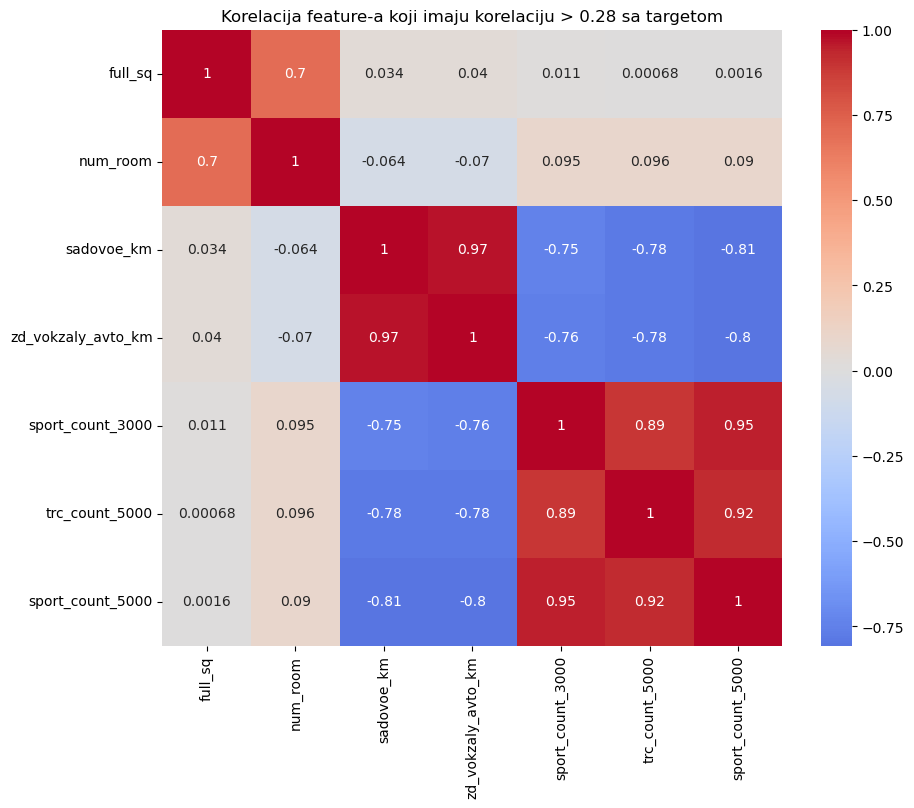

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(df[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [60]:
target = "price_doc"

# Uzmi samo numeričke kolone
#df_num = df.select_dtypes(include=["int64", "float64"])

# Korelacija svih feature-a sa targetom (apsolutne vrednosti)
target_corr = df_num.corr()[target].abs()

# Filtriraj po pragu |corr| > 0.28
selected_features = target_corr[target_corr > 0.28].index.tolist()

# Napravi novi DataFrame (samo izabrane kolone + target)
df_filtered = df_num[selected_features]

print("Kolone u novom df:", df_filtered.columns.tolist())
print("Shape novog df:", df_filtered.shape)

df_filtered.head()

Kolone u novom df: ['full_sq', 'num_room', 'sadovoe_km', 'zd_vokzaly_avto_km', 'sport_count_3000', 'trc_count_5000', 'sport_count_5000', 'price_doc']
Shape novog df: (30471, 8)


,full_sq,num_room,sadovoe_km,zd_vokzaly_avto_km,sport_count_3000,trc_count_5000,sport_count_5000,price_doc
0,43,NaN,13.100618,14.231961,21,52,52,5850000
1,34,NaN,6.444333,9.242586,19,40,66,6000000
2,43,NaN,6.963403,9.540544,20,35,67,5700000
3,89,NaN,17.457198,17.478380,18,22,26,13100000
4,77,NaN,0.046810,1.595898,77,114,195,16331452


In [62]:
# korak 1: napravi korelacionu matricu za df_filtered (bez targeta)
corr_matrix = df_filtered.drop(columns=[target]).corr()

# korak 2: pronađi parove sa korelacijom > 0.85 (po apsolutnoj vrednosti)
high_corr_pairs = [
    (col1, col2, corr_matrix.loc[col1, col2])
    for col1 in corr_matrix.columns
    for col2 in corr_matrix.columns
    if col1 < col2 and abs(corr_matrix.loc[col1, col2]) > 0.85
]

print("Parovi kolona sa međusobnom korelacijom |corr| > 0.85:")
for col1, col2, val in high_corr_pairs:
    print(f"{col1} - {col2}  (korelacija: {val:.2f})")


Parovi kolona sa međusobnom korelacijom |corr| > 0.85:
sadovoe_km - zd_vokzaly_avto_km  (korelacija: 0.97)
sport_count_3000 - trc_count_5000  (korelacija: 0.89)
sport_count_3000 - sport_count_5000  (korelacija: 0.95)
sport_count_5000 - trc_count_5000  (korelacija: 0.92)


In [64]:
target = "price_doc"

# korak 1: korelaciona matrica između feature-a (bez targeta)
corr_matrix = df_filtered.drop(columns=[target]).corr().abs()

# korak 2: pronađi parove sa međusobnom korelacijom > 0.85
high_corr_pairs = [
    (col1, col2)
    for col1 in corr_matrix.columns
    for col2 in corr_matrix.columns
    if col1 < col2 and corr_matrix.loc[col1, col2] > 0.85
]

# korak 3: od svakog para zadrži onu kolonu sa manjom korelacijom prema targetu
to_drop = []
for col1, col2 in high_corr_pairs:
    if target_corr[col1] < target_corr[col2]:
        to_drop.append(col1)
    else:
        to_drop.append(col2)

print("Kolone koje treba izbaciti (slabija korelacija sa targetom):")
print(to_drop)

# ako želiš novi df bez tih kolona:
df_final = df_filtered.drop(columns=to_drop)

print("Shape finalnog df:", df_final.shape)
df_final.head()


Kolone koje treba izbaciti (slabija korelacija sa targetom):
['sadovoe_km', 'trc_count_5000', 'sport_count_3000', 'trc_count_5000']
Shape finalnog df: (30471, 5)


,full_sq,num_room,zd_vokzaly_avto_km,sport_count_5000,price_doc
0,43,NaN,14.231961,52,5850000
1,34,NaN,9.242586,66,6000000
2,43,NaN,9.540544,67,5700000
3,89,NaN,17.478380,26,13100000
4,77,NaN,1.595898,195,16331452


In [70]:
df_final["num_room"].isna().sum()

30471